In [2]:
import pandas as pd 
import numpy as np 


df = pd.read_csv("/Users/nakul/Desktop/PHYS/Equity-Signal-/data/ratio_with_returns.csv")
df["snapshot"] = pd.to_datetime(df["snapshot"])

print("Shape:", df.shape)
print("\nYears available:", sorted(df["snapshot"].dt.year.unique()))

years = sorted(df["snapshot"].dt.year.unique())
n_years = len(years)

n_train = int(n_years * 0.70)
n_val = int(n_years * 0.15)
#train_years = years[:n_train]
#val_years = years[n_train:n_train + n_val]
#test_years = years[n_train + n_val:]

train_years = [y for y in years if y <= 2020]
val_years = [y for y in years if y in (2021, 2022)]
test_years = [y for y in years if y >= 2023]


print(f"\nTrain years: {train_years}")
print(f"Val years:   {val_years}")
print(f"Test years:  {test_years}")

train_df = df[df["snapshot"].dt.year.isin(train_years)].copy()
val_df = df[df["snapshot"].dt.year.isin(val_years)].copy()
test_df = df[df["snapshot"].dt.year.isin(test_years)].copy()

print(f"\nTrain rows: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val rows:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test rows:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

feature_cols = ["ROE", "ROA", "GrossMargin", "DebtToEquity", "AssetTurnover", "EPS"]
target_col = "excess_return"

X_train = train_df[feature_cols].values
y_train = train_df[target_col].values

X_val = val_df[feature_cols].values
y_val = val_df[target_col].values

X_test = test_df[feature_cols].values
y_test = test_df[target_col].values

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")



Shape: (28331, 30)

Years available: [np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

Train years: [np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]
Val years:   [np.int32(2021), np.int32(2022)]
Test years:  [np.int32(2023), np.int32(2024), np.int32(2025)]

Train rows: 15164 (53.5%)
Val rows:   4848 (17.1%)
Test rows:  8319 (29.4%)

X_train shape: (15164, 6), y_train shape: (15164,)
X_val shape:   (4848, 6), y_val shape:   (4848,)
X_test shape:  (8319, 6), y_test shape:  (8319,)


In [3]:
feature_cols = ["ROE", "ROA", "GrossMargin", "DebtToEquity", "AssetTurnover", "EPS"]
target_col = "excess_return"

print("Before dropping NaNs:")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

train_df = train_df.dropna(subset=feature_cols + [target_col]).copy()
val_df = val_df.dropna(subset=feature_cols + [target_col]).copy()
test_df = test_df.dropna(subset=feature_cols + [target_col]).copy()

print("\nAfter dropping NaNs (all feature columns):")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

X_train = train_df[feature_cols].values
y_train = train_df[target_col].values

X_val = val_df[feature_cols].values
y_val = val_df[target_col].values

X_test = test_df[feature_cols].values
y_test = test_df[target_col].values

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

print(f"\nAny NaNs left in X_train? {np.isnan(X_train).any()}")
print(f"Any NaNs left in X_val?   {np.isnan(X_val).any()}")
print(f"Any NaNs left in X_test?  {np.isnan(X_test).any()}")

Before dropping NaNs:
Train: 15164, Val: 4848, Test: 8319

After dropping NaNs (all feature columns):
Train: 9257, Val: 2792, Test: 4797

X_train shape: (9257, 6), y_train shape: (9257,)
X_val shape:   (2792, 6), y_val shape:   (2792,)
X_test shape:  (4797, 6), y_test shape:  (4797,)

Any NaNs left in X_train? False
Any NaNs left in X_val?   False
Any NaNs left in X_test?  False


In [4]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_val_scaled = (X_val - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

def add_intercept(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = add_intercept(X_train_scaled)
X_val_b = add_intercept(X_val_scaled)
X_test_b = add_intercept(X_test_scaled)


def compute_mse(X, y, theta):
    predicitions = X @ theta #compute y manually using theta 
    errors = predicitions - y 
    return np.mean(errors **2)

def gradient_descent(X, y, learning_rate=0.01, n_iterations=1000):
    n_samples, n_features = X.shape
    theta = np.zeros(n_features)
    loss_history = []
    gradient_history = []

    for i in range(n_iterations):
        predictions = X @ theta
        errors = predictions - y
        gradient = (2 / n_samples) * (X.T @ errors)
        theta = theta - learning_rate * gradient

        loss = np.mean(errors ** 2)
        loss_history.append(loss)
        gradient_norm = np.linalg.norm(gradient)
        gradient_history.append(gradient_norm)

    return theta, loss_history, gradient_history

theta, loss_history, gradient_history = gradient_descent(X_train_b, y_train, learning_rate=0.01, n_iterations=50000)

print("\nFinal training MSE:", loss_history[-1])
print("Initial training MSE:", loss_history[0])

print("\nFinal gradient:", gradient_history[-1])
print("Initial gradient:", gradient_history[0])

print("\nLearned parameters (theta):")
feature_names = ["intercept"] + feature_cols
for name, val in zip(feature_names, theta):
    print(f"  {name}: {val:.6f}")

val_mse = compute_mse(X_val_b, y_val, theta)
print(f"\nValidation MSE: {val_mse:.6f}")   



Final training MSE: 0.22042816737241652
Initial training MSE: 0.22290546864178695

Final gradient: 4.385334152983338e-16
Initial gradient: 0.0883240649214937

Learned parameters (theta):
  intercept: 0.023004
  ROE: 0.002458
  ROA: 0.013271
  GrossMargin: 0.034213
  DebtToEquity: 0.010716
  AssetTurnover: 0.027060
  EPS: -0.024033

Validation MSE: 0.209271


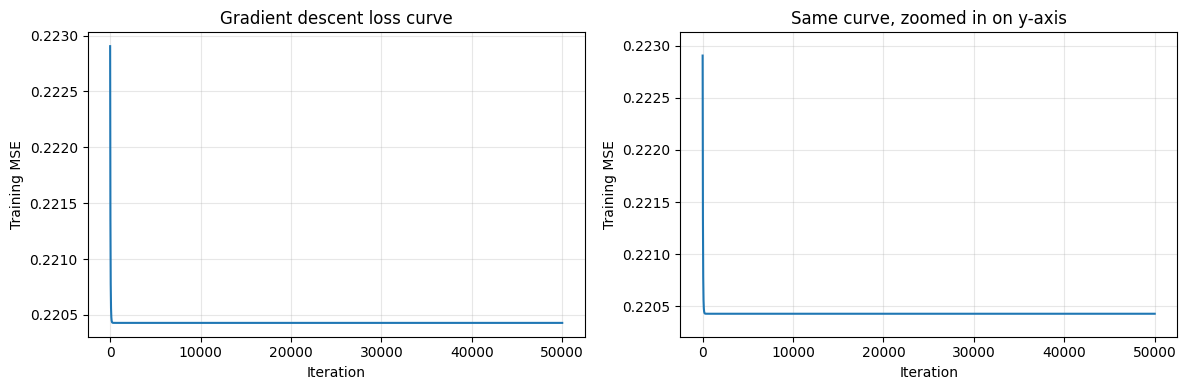

Initial loss: 0.222905
Final loss:   0.220428
Total reduction: 0.002477 (1.11%)


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: full loss curve, linear scale
axes[0].plot(loss_history)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Training MSE")
axes[0].set_title("Gradient descent loss curve")
axes[0].grid(True, alpha=0.3)

# Right: same curve but zoomed in on the y-axis to make the small movement visible
axes[1].plot(loss_history)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Training MSE")
axes[1].set_title("Same curve, zoomed in on y-axis")
axes[1].set_ylim(min(loss_history) * 0.999, max(loss_history) * 1.001)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Initial loss: {loss_history[0]:.6f}")
print(f"Final loss:   {loss_history[-1]:.6f}")
print(f"Total reduction: {(loss_history[0] - loss_history[-1]):.6f} "
      f"({(1 - loss_history[-1]/loss_history[0])*100:.2f}%)")

In [6]:
Xtx = X_train_b.T @ X_train_b
Xty = X_train_b.T @ y_train
theta_normal = np.linalg.solve(Xtx, Xty)

print("Normal Equation thetas:")
for name, val in zip(feature_names, theta_normal):
    print(f" {name}: {val:.6f}")

print("\nSide by side comparison (Normal Equation vs Gradient Descent):")
print(f"{'feature':<15} {'normal_eq':>12} {'grad_desc':>12} {'diff':>12}")
for name, ne, gd in zip(feature_names, theta_normal, theta):
    print(f"{name:<15} {100*ne:>12.6f} {100*gd:>12.6f} {ne - gd:>12.6f}")

# Compute MSE on train and val with the Normal Equation thetas
train_mse_normal = compute_mse(X_train_b, y_train, theta_normal)
val_mse_normal = compute_mse(X_val_b, y_val, theta_normal)

print(f"\nNormal Equation - Train MSE: {train_mse_normal:.6f}")
print(f"Normal Equation - Val MSE:   {val_mse_normal:.6f}")
print(f"\nGradient Descent - Final Train MSE: {loss_history[-1]:.6f}")
print(f"Gradient Descent - Val MSE:         {val_mse:.6f}")

Normal Equation thetas:
 intercept: 0.023004
 ROE: 0.002458
 ROA: 0.013271
 GrossMargin: 0.034213
 DebtToEquity: 0.010716
 AssetTurnover: 0.027060
 EPS: -0.024033

Side by side comparison (Normal Equation vs Gradient Descent):
feature            normal_eq    grad_desc         diff
intercept           2.300430     2.300430     0.000000
ROE                 0.245763     0.245763    -0.000000
ROA                 1.327114     1.327114     0.000000
GrossMargin         3.421287     3.421287    -0.000000
DebtToEquity        1.071620     1.071620    -0.000000
AssetTurnover       2.705965     2.705965    -0.000000
EPS                -2.403306    -2.403306    -0.000000

Normal Equation - Train MSE: 0.220428
Normal Equation - Val MSE:   0.209271

Gradient Descent - Final Train MSE: 0.220428
Gradient Descent - Val MSE:         0.209271


In [7]:
#R^2 calculation 

def r_squared(X, y, theta, y_mean_baseline):
    """
    X, y: data to evaluate on
    theta: fitted parameters
    y_mean_baseline: the mean to compare against
    """
    y_pred = X @ theta 
    ss_res = np.sum((y-y_pred)**2)
    ss_tot = np.sum((y-y_mean_baseline)**2)
    return 1 - (ss_res/ ss_tot) 

y_train_mean = y_train.mean()

r2_train = r_squared(X_train_b, y_train, theta_normal, y_train_mean)
r2_val = r_squared(X_val_b, y_val, theta_normal, y_train_mean)


print(f"R^2 on train: {r2_train:.6f}")
print(f"R^2 on val:   {r2_val:.6f}")

for label, r2 in [("Train", r2_train), ("Val", r2_val)]:
    pct = r2 * 100
    print(f"{label}: model explains {pct:.3f}% of the variance in excess returns "
          f"beyond just guessing the mean")


R^2 on train: 0.008760
R^2 on val:   0.000132
Train: model explains 0.876% of the variance in excess returns beyond just guessing the mean
Val: model explains 0.013% of the variance in excess returns beyond just guessing the mean


In [8]:
#R^2 by year 

def r2_by_year(df_split, X_b_split, y_split, theta, y_mean_baseline):
    """
    df_split: the dataframe for this split used only to get the snapshot year for grouping
    X_b_split: the strandized feature matrix for this split 
    y_split: true target values for this split
    theta: fitted parameters
    y_mean_baseline: the baseline mean  to compare against
    """

    years = pd.to_datetime(df_split["snapshot"]).dt.year.values
    y_pred = X_b_split @ theta 

    results = []
    for year in sorted(set(years)):
        mask = years == year 
        y_true_year = y_split[mask]
        y_pred_year = y_pred[mask]

        ss_res = np.sum((y_true_year - y_pred_year)**2)
        ss_tot = np.sum((y_true_year - y_mean_baseline)**2)
        r2_year = 1 - (ss_res / ss_tot)

        results.append({
            "year": year,
            "n_samples": mask.sum(),
            "r2": r2_year
        })

    return pd.DataFrame(results)

print("Per-year R^2 on TRAIN:")
train_r2_by_year = r2_by_year(train_df, X_train_b, y_train, theta_normal, y_train_mean)
print(train_r2_by_year.to_string(index=False))

print("\nPer-year R^2 on VAL:")
val_r2_by_year = r2_by_year(val_df, X_val_b, y_val, theta_normal, y_train_mean)
print(val_r2_by_year.to_string(index=False))

Per-year R^2 on TRAIN:
 year  n_samples        r2
 2013       1020  0.005124
 2014       1053  0.017044
 2015       1087  0.018418
 2016       1144 -0.009017
 2017       1179  0.012920
 2018       1230  0.037820
 2019       1223  0.009623
 2020       1321 -0.000057

Per-year R^2 on VAL:
 year  n_samples        r2
 2021       1379  0.007967
 2022       1413 -0.015321


In [9]:
from scipy.stats import spearmanr 

#IC calculation

def information_coefficient_by_year(df_split, X_b_split, y_split, theta):
    """ 
    For each year in df_split, compute the Spearman rank correlation between
    predicted and actual excess returns.
    """

    years = pd.to_datetime(df_split["snapshot"]).dt.year.values
    y_pred = X_b_split @ theta 

    results = []
    for year in sorted(set(years)):
        mask = years == year
        y_true_year = y_split[mask]
        y_pred_year = y_pred[mask]

        ic, p_value = spearmanr(y_pred_year, y_true_year)

        results.append({
            "year": year,
            "n_samples": mask.sum(),
            "IC": ic,
            "p_value": p_value
        })
    
    return pd.DataFrame(results)



print("Information Coefficient (IC) by year - TRAIN:")
train_ic = information_coefficient_by_year(train_df, X_train_b, y_train, theta_normal)
print(train_ic.to_string(index=False))
print(f"\nMean IC (train): {train_ic['IC'].mean():.4f}")
print(f"Std of IC (train): {train_ic['IC'].std():.4f}")

print("\nInformation Coefficient (IC) by year - VAL:")
val_ic = information_coefficient_by_year(val_df, X_val_b, y_val, theta_normal)
print(val_ic.to_string(index=False))
print(f"\nMean IC (val): {val_ic['IC'].mean():.4f}")
print(f"Std of IC (val): {val_ic['IC'].std():.4f}")


ir_train = train_ic["IC"].mean() / train_ic["IC"].std()
ir_val = val_ic["IC"].mean() / val_ic["IC"].std() if len(val_ic) > 1 else float("nan")
print(f"\nIC Information Ratio (train): {ir_train:.4f}")
print(f"IC Information Ratio (val):   {ir_val:.4f}")

Information Coefficient (IC) by year - TRAIN:
 year  n_samples        IC      p_value
 2013       1020  0.058881 6.013203e-02
 2014       1053  0.117258 1.369181e-04
 2015       1087  0.117318 1.058074e-04
 2016       1144 -0.045658 1.227308e-01
 2017       1179  0.099429 6.287152e-04
 2018       1230  0.231900 1.761241e-16
 2019       1223  0.028363 3.216499e-01
 2020       1321  0.107265 9.376120e-05

Mean IC (train): 0.0893
Std of IC (train): 0.0803

Information Coefficient (IC) by year - VAL:
 year  n_samples        IC  p_value
 2021       1379  0.020231 0.452841
 2022       1413 -0.083040 0.001784

Mean IC (val): -0.0314
Std of IC (val): 0.0730

IC Information Ratio (train): 1.1121
IC Information Ratio (val):   -0.4301


In [10]:
def ridge_normal_equation(X, y, lam):
    n_features = X.shape[1]
    I = np.eye(n_features)
    I[0,0] = 0 
    theta = np.linalg.solve(X.T @ X + lam * I, X.T @ y)
    return theta 

#sweep over a range of lambda values fit on train, evaluate on validate 

lambdas = [0,0.01,0.1,1,10,50,100,500,1000]
results = []


for lam in lambdas:
    theta_ridge = ridge_normal_equation(X_train_b, y_train, lam)

    train_mse_ridge = compute_mse(X_train_b, y_train, theta_ridge)
    val_mse_ridge = compute_mse(X_val_b, y_val, theta_ridge)

    r2_train_ridge = r_squared(X_train_b, y_train, theta_ridge, y_train_mean)
    r2_val_ridge = r_squared(X_val_b, y_val, theta_ridge, y_train_mean)

    results.append({
        "lambda": lam,
        "train_mse": train_mse_ridge,
        "val_mse": val_mse_ridge,
        "train_r2": r2_train_ridge,
        "val_r2": r2_val_ridge,
        "theta_norm": np.linalg.norm(theta_ridge[1:])  # exclude intercept from norm too
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best_lambda = results_df.loc[results_df["val_r2"].idxmax(), "lambda"]
print(f"\nBest lambda by val R^2: {best_lambda}")

 lambda  train_mse  val_mse  train_r2   val_r2  theta_norm
   0.00   0.220428 0.209271  0.008760 0.000132    0.052700
   0.01   0.220428 0.209271  0.008760 0.000132    0.052700
   0.10   0.220428 0.209271  0.008760 0.000132    0.052700
   1.00   0.220428 0.209271  0.008760 0.000134    0.052692
  10.00   0.220428 0.209267  0.008760 0.000151    0.052617
  50.00   0.220428 0.209252  0.008760 0.000226    0.052288
 100.00   0.220429 0.209233  0.008758 0.000318    0.051882
 500.00   0.220438 0.209096  0.008715 0.000972    0.048858
1000.00   0.220463 0.208959  0.008603 0.001623    0.045553

Best lambda by val R^2: 1000.0


In [11]:
# FINAL TEST EVALUATION - run once, no further tuning after seeing this.
# Using theta_normal (unregularized, since ridge didn't meaningfully help)
# for linear regression.

print("=" * 50)
print("LINEAR REGRESSION - TEST SET")
print("=" * 50)

test_mse = compute_mse(X_test_b, y_test, theta_normal)
test_r2 = r_squared(X_test_b, y_test, theta_normal, y_train_mean)

print(f"Test MSE: {test_mse:.6f}")
print(f"Test R^2: {test_r2:.6f} ({test_r2*100:.3f}%)")

print("\nPer-year R^2 on TEST:")
test_r2_by_year = r2_by_year(test_df, X_test_b, y_test, theta_normal, y_train_mean)
print(test_r2_by_year.to_string(index=False))

print("\nInformation Coefficient (IC) by year - TEST:")
test_ic = information_coefficient_by_year(test_df, X_test_b, y_test, theta_normal)
print(test_ic.to_string(index=False))
print(f"\nMean IC (test): {test_ic['IC'].mean():.4f}")
print(f"Std of IC (test): {test_ic['IC'].std():.4f}")

LINEAR REGRESSION - TEST SET
Test MSE: 0.322283
Test R^2: 0.007725 (0.772%)

Per-year R^2 on TEST:
 year  n_samples       r2
 2023       1563 0.006316
 2024       1592 0.015629
 2025       1642 0.000382

Information Coefficient (IC) by year - TEST:
 year  n_samples        IC  p_value
 2023       1563  0.014386 0.569824
 2024       1592  0.063989 0.010656
 2025       1642 -0.023391 0.343505

Mean IC (test): 0.0183
Std of IC (test): 0.0438
